# Recipe example

---

#### Coursera
#### Course: `Agentic AI with LangGraph, CrewAI, AutoGen and BeeAI`

#### Module1

#### Lab: `Build LangGraph Design Patterns: Orchestration & Evaluation`

## imports


In [43]:
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send
from langchain_core.runnables import RunnableLambda, Runnable

## imports for type safety

In [44]:
from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
import operator
from pprint import pprint

## Imports for graph visualization of our workflow:

In [45]:
from IPython.display import Image, display

## environments


In [46]:
from dotenv import load_dotenv
import os
from pathlib import Path

# Load environment variables from your custom .env location
env_path = Path.home() / "Source" / "SECRETS" / ".env"
load_dotenv(env_path)

# Now you can use the environment variables
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate



## llm instantiation

In [47]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Initialize the language model - using gpt-4o-mini for cost-effective experimentation
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

## Dish Schema (Structured Output)

#### Dish

In [48]:
# Dish schema for a single dish
class Dish(BaseModel):
    name: str = Field(
        description="Name of the dish (for example, Spaghetti Bolognese, Chicken Curry)."
    )
    ingredients: List[str] = Field(
        description="List of ingredients needed for this dish, separated by commas."
    )
    location: str = Field(
        description="The cuisine or cultural origin of the dish (for example, Italian, Indian, Mexican)."
    )



#### Dishes

In [49]:
# Dishes schema for a list of Dish objects
class Dishes(BaseModel):
    sections: List[Dish] = Field(
        description="A list of grocery sections, one for each dish, with ingredients."
    )

## State Schema


#### State

In [50]:
class State(TypedDict):
    meals: List[str]  # The user's input listing the meals to prepare

    sections: List[Dish] # One section per meal/dish with ingredients

    """
    completed_menu:
    What it is: an accumulator of text chunks produced by workers (each chunk is a str).
    Why Annotated[..., operator.add] exists: to tell LangGraph how to merge multiple updates to the same key.
    """
    completed_menu: Annotated[List[str], operator.add]  # Worker written dish guide chunks

    final_meal_guide: str  # Fully compiled, readable menu

#### WorkerState

In [51]:
class WorkerState(TypedDict):
    section: Dish
    completed_menu: Annotated[list, operator.add] # list with addition operators between elements

# Prompts
---

#### Dish Prompt

In [52]:
# construct a prompt template
dish_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an assistant that generates a structured grocery list.\n\n"
        "The user wants to prepare the following meals: {meals}\n\n"
        "For each meal, return a section with:\n"
        "- the name of the dish\n"
        "- a comma-separated list of ingredients needed for that dish.\n"
        "- the cuisine or cultural origin of the food"
    )
])

#### Chef Prompt

In [53]:
chef_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a world-class chef from {location}.\n\n"
        "Please introduce yourself briefly and present a detailed walkthrough for preparing the dish: {name}.\n"
        "Your response should include:\n"
        "- Start with hello with your  name and culinary background\n"
        "- A clear list of preparation steps\n"
        "- A full explanation of the cooking process\n\n"
        "Use the following ingredients: {ingredients}."
    )
])

chef_pipe = chef_prompt | llm

## Pipelines

---


In [54]:
planner_pipe = dish_prompt | llm.with_structured_output(Dishes)

In [55]:
chef_pipe = chef_prompt | llm

### Nodes
---


In [56]:
def orchestrator(state: State):
    """Orchestrator that generates a structured dish list from the given meals."""

    # use the planner_pipe LLM to break the user's meal list into structured dish sections
    dish_descriptions = planner_pipe.invoke({"meals": state["meals"]})

    # return the list of dish sections to be passed to worker nodes
    return {"sections": dish_descriptions.sections}

In [57]:
def chef_worker(state: WorkerState):
    """Worker node that generates the cooking instructions for one meal section."""

    # Use the language model to generate a meal preparation plan
    # The model receives the dish name, location, and ingredients from the current section
    meal_plan = chef_pipe.invoke({
        "name": state["section"].name,
        "location": state["section"].location,
        "ingredients": state["section"].ingredients
    })

    # Return the generated meal plan wrapped in a list under completed_sections
    # This will be merged into the main state using operator.add in LangGraph
    return {"completed_menu": [meal_plan.content]}

In [58]:
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # list of completed sections
    completed_sections = state["completed_menu"]

    # format completed section to str to use as context for final sections
    completed_menu = "\n\n---\n\n".join(completed_sections)

    return {"final_meal_guide": completed_menu}

#### Routing functions

In [59]:
def assign_workers(state: State):
    """Assign a worker to each section in the plan."""
    return [
        Send(
            "chef_worker",
            WorkerState(
                section=s,
                completed_menu=[]  # Explicitly initialize
            )
        )
        for s in state["sections"]
    ]

## Graph

#### instantiate a StateGraph

In [60]:
# instantiate the builder
orchestrator_worker_builder = StateGraph(State)


### add nodes

In [ ]:
from langchain_core.runnables import RunnableLambda, Runnable
from typing import Callable, Any

def node(name: str, fn: Callable[..., dict], *, retry: bool = False) -> Runnable:
    r: Runnable = RunnableLambda(fn).with_config(
        tags=[f"node:{name}"],
        metadata={"node_name": name},
    )
    if retry:
        r = r.with_retry(stop_after_attempt=3)
    return r

In [61]:
# add the nodes  TODO - still need to decide on how we cam add_nodes to StateGraph

orchestrator_worker_builder.add_node("orchestrator", node("orchestrator", orchestrator))
orchestrator_worker_builder.add_node("chef_worker", chef_worker)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

## add edges

In [62]:
# add # Start to orchestrator
orchestrator_worker_builder.add_edge(START, "orchestrator")

# orchestrator to chef_worker...
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator",  # source node
    assign_workers,  # routing function
    ["chef_worker"]  # list of allowed targets
)

# chef_worker to synthesizer
orchestrator_worker_builder.add_edge("chef_worker", "synthesizer")

# synthesizer to END
orchestrator_worker_builder.add_edge("synthesizer", END)

# compile the graph


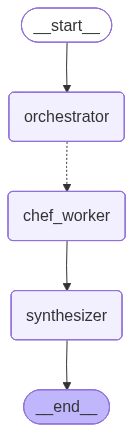

In [63]:
# compile the builder to get a complete workflow executable
orchestrator_worker = orchestrator_worker_builder.compile()

# display the orchestrator workflow using mermaid chart
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [64]:
# invoke the workflow with a string of meals in a dict
state = orchestrator_worker.invoke({"meals": "Steak and eggs, tacos, and chili"})
# print the first 2000 characters of our final_meal_guide
pprint(state["final_meal_guide"][:2000])

('Hello! My name is Chef Alex, and I have over a decade of experience in the '
 'culinary arts, specializing in American cuisine. Today, I’m excited to share '
 'with you a classic and hearty dish: Steak and Eggs. This dish is perfect for '
 "breakfast, brunch, or even a satisfying dinner. Let's dive right into the "
 'preparation!\n'
 '\n'
 '### Ingredients\n'
 '- 1 Ribeye or New York Strip Steak (about 1 inch thick)\n'
 '- 2 large eggs\n'
 '- Salt (to taste)\n'
 '- Freshly cracked black pepper (to taste)\n'
 '- 2 tablespoons of unsalted butter\n'
 '\n'
 '### Preparation Steps\n'
 '\n'
 '1. **Choose the Steak**: Select a high-quality cut of steak. Ribeye or New '
 'York Strip work beautifully for this dish due to their marbling and flavor.\n'
 '\n'
 '2. **Season the Steak**: Take the steak out of the refrigerator 30 minutes '
 'before cooking to bring it to room temperature. Season generously with salt '
 'and freshly cracked black pepper on both sides.\n'
 '\n'
 '3. **Prepare the Egg